# Function 2: 2D Mystery ML Model

*Analogy: Tuning a simple machine learning model to maximize its log-likelihood score.*

### Characteristics

* Noisy: "Each output is noisy." The observed $y$ varies ($y + \epsilon$). Querying $(x_1, x_2)$ twice yields different results.

* Landscape: "Complex functions with many local peaks." There is a high risk of getting stuck in a local optimum.

* Strategy: Requires balancing exploration (checking new areas) vs exploitation (refining known good spots) to handle noise.

## 1. Setup and load data

In [67]:
# ==== External libraries ====
import sys
import copy
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # registers the 3D projection
from pathlib import Path
from scipy.stats import norm
import matplotlib.pyplot as plt
from matplotlib import cm

# ==== Project path + internal utilities ====
repo_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(repo_root))
from src.utils.load_challenge_data import (
    load_function_data,
    load_problem_data_csv,
    assert_not_under_initial_data,
)
from src.utils.warping import apply_output_warping
from src.utils.sampling_utils import sample_candidates
from src.utils.plot_utilities import (
    prepare_surface_for_plot as _prepare_surface_for_plot,
    setup_matplotlib,
)

setup_matplotlib()

# Figure sizes (inches) — consistent across this notebook
F2_FIG_1X2 = (12.0, 5.0)
F2_FIG_1X2_LINE = (12.0, 4.5)
F2_FIG_1X3 = (16.0, 5.0)
F2_FIG_3X2 = (12.0, 14.0)
F2_FIG_1X1 = (12.0, 5.0)
F2_FIG_3D = (10.0, 7.5)

np.random.seed(42)


In [68]:
# Load: under data/ we use only CSV. observations.csv if present, else initial_data (read-only).
local_dir = repo_root / "data" / "problems" / "function_2"
csv_path = local_dir / "observations.csv"
PLOT_EXPORT_DIR = repo_root / "data" / "results" / "function_2"
print('Set data directory to', local_dir)

Set data directory to /Users/nikolaskarefyllidis/Desktop/60_ML-AI/10 main optimization/10 ICL BBO Challenge/black-box-optimization/data/problems/function_2


In [69]:
# Run-time flags — toggle without re-running the whole notebook
IF_SHOW_PLOT      = True   # call plt.show() after each figure
IF_EXPORT_PLOT    = False  # save figures to PLOT_EXPORT_DIR
IF_EXPORT_QUERIES = True   # write next_x to data/submissions/
IF_APPEND_DATA    = False  # append new observation to observations.csv

# ==== Plot style options (line widths, legend, contours) ====
CONTOURF_LEVELS     = 30    # number of filled contour levels (contourf)
CONTOUR_LINE_LEVELS = 11    # number of contour line levels (contour overlay)
CONTOUR_LINEWIDTH   = 1.0   # linewidth for contour() overlay
CONTOUR_LINESTYLE   = "-"   # linestyle: "-" | "--" | ":"
CONTOUR_ALPHA       = 0.5   # alpha for contour lines
SCATTER_EDGE_LW     = 1.5   # scatter marker edge linewidth
LEGEND_FONTSIZE     = 9
LEGEND_LOC          = "upper right"   # "lower right" | "lower center" | etc.
LEGEND_FRAMEALPHA   = 0.95
LEGEND_NCOL         = 7     # columns for shared legend (Section 5)

print('Control flags set')


Control flags set


In [70]:
############################################
# SELECT OPTIMIZATION ALGORITHM SOLUTION EXPORT #
############################################
# Which solver's suggestion to save to data/submissions/function_2/.
# Use exactly one of the Section 6 keys: 'MyBO', 'Optuna-TPE', 'Optuna-GP', 'TuRBO', 'DE-GP-EI'
NEXT_QUERY_SOLUTION = "MyBO"
NEXT_QUERY_SOLUTION = NEXT_QUERY_SOLUTION.strip()

print(50*'=')
print(f'NEXT_QUERY_SOLUTION = {NEXT_QUERY_SOLUTION}')
print(50*'=')

NEXT_QUERY_SOLUTION = MyBO


In [71]:
# ==== Probabilistic surrogate models (sklearn) ====
# GaussianProcessRegressor: fits GP to (X, y); predict() returns posterior μ and σ.
from sklearn.gaussian_process import GaussianProcessRegressor

from sklearn.gaussian_process.kernels import (RBF, Matern, ConstantKernel, WhiteKernel,)

# ==== Acquisition functions (skopt) ====
from skopt.acquisition import (gaussian_ei, gaussian_pi, gaussian_lcb)

# ==== Candidate samplers (skopt) ====
from skopt.sampler import (Lhs, Sobol)


In [72]:
# ==== GP kernel hyperparameters ====
CONSTANT_KERNEL_SCALE = 1.0    # output-scale; normalized y so value matters little
LENGTH_SCALE          = 1.0    # init length-scale; sklearn optimizes this — lower = wigglier
GP_ALPHA              = 1e-6   # nugget for numerical stability; raise to 1e-4 if Cholesky fails
MATERN_NU             = 1.5    # roughness: 0.5=exp, 1.5=C¹, 2.5=C², ∞=RBF
WHITE_NOISE_LEVEL     = 1e-3   # noise init; raise to 0.01-0.1 if oracle is stochastic
GP_KERNEL             = None   # Option to pass: None or "none" → LML auto-select; "RBF" | "Matern" | "RBF + WhiteKernel" → use that kernel

OPTIMIZE_KERNEL       = True  # Optimize kernel hyperparameters (if True use best kernel)
N_RESTARTS_KERNEL     = 25      # 2D: moderate restarts for LML landscape
CONSTANT_SCALE_BOUNDS = (0.1, 10)    # bounds for ConstantKernel output-scale
LENGTH_SCALE_BOUNDS   = (0.01, 10)   # lower 0.01 so optimizer can use short length-scales; upper 10 to avoid runaway
WHITE_NOISE_BOUNDS    = (1e-5, 1.0)  # upper 1.0 so optimizer is not constrained at noise upper bound

# ==== Output warping (HEBO-inspired) ====
# If you switch to "log" or "boxcox", add the same mode for function_id 2 in
# src/utils/compare_solvers._OUTPUT_WARPING_BY_FUNCTION_ID so batch runs match this notebook.
OUTPUT_WARPING = "None"    # None | "boxcox" | "log" — transform y before GP fit; acquisition/next_x in warped space

# ==== Acquisition coefficients ====
# Early (few obs): explore → high ξ/κ.  Late (many obs): exploit → low ξ/κ.
XI_EI_PI  = 0.15     # ξ for EI/PI: 0.25 = explore, 0.05 = exploit near best
KAPPA_UCB = 3.0     # κ for UCB:   3-5  = explore, 1-2  = exploit near mean peak

# ==== Candidate sampling ====
n_grid  = 500   # 2D grid resolution (for plotting and candidate sampling)
n_cand  = n_grid * n_grid
CANDIDATE_SAMPLING_METHOD = "lhs"  #  'lhs' | 'sobol'

# ==== Option to use Ensemble for acquisition function ====
USE_ENSEMBLE    = True   # Set False to use SOLO_STRATEGY only
SOLO_STRATEGY   = "UCB" # Used when USE_ENSEMBLE=False: "EI" | "PI" | "UCB"
AGREE_THRESHOLD = 0.15  # max pairwise L2 dist; if exceeded, use centroid
MIN_DIST_THRESHOLD = 0.05  # min L2 distance from any obs; mask acquisition at closer candidates
BOUNDARY_MARGIN = 0.05     # 0=off. Mask candidates near edges; low-d only; high-d use 0


In [73]:
# Prefer local CSV (updated each week); fall back to read-only initial data
if csv_path.exists():
    X, y = load_problem_data_csv(csv_path)
else:
    X, y = load_function_data(function_id=2)
y_orig = np.asarray(y, dtype=np.float64).copy()
y, warp_params, _msg = apply_output_warping(y_orig, mode=OUTPUT_WARPING)
print(_msg)
WARP_LABEL = (warp_params[0] if warp_params else "None")
best_idx = np.argmax(y)
best_y, best_x_so_far = y[best_idx], X[best_idx]
print(f"Loaded: X{X.shape}, y{y.shape}. Best: y={best_y:.4g} at x=({best_x_so_far[0]:.4f}, {best_x_so_far[1]:.4f}), n={len(y)}.")


Output warping: None. GP fits raw y. No transform applied.
Loaded: X(19, 2), y(19,). Best: y=0.7248 at x=(0.6997, 0.0678), n=19.


### Progress
Left: y per query. Right: best y so far (cumulative max).

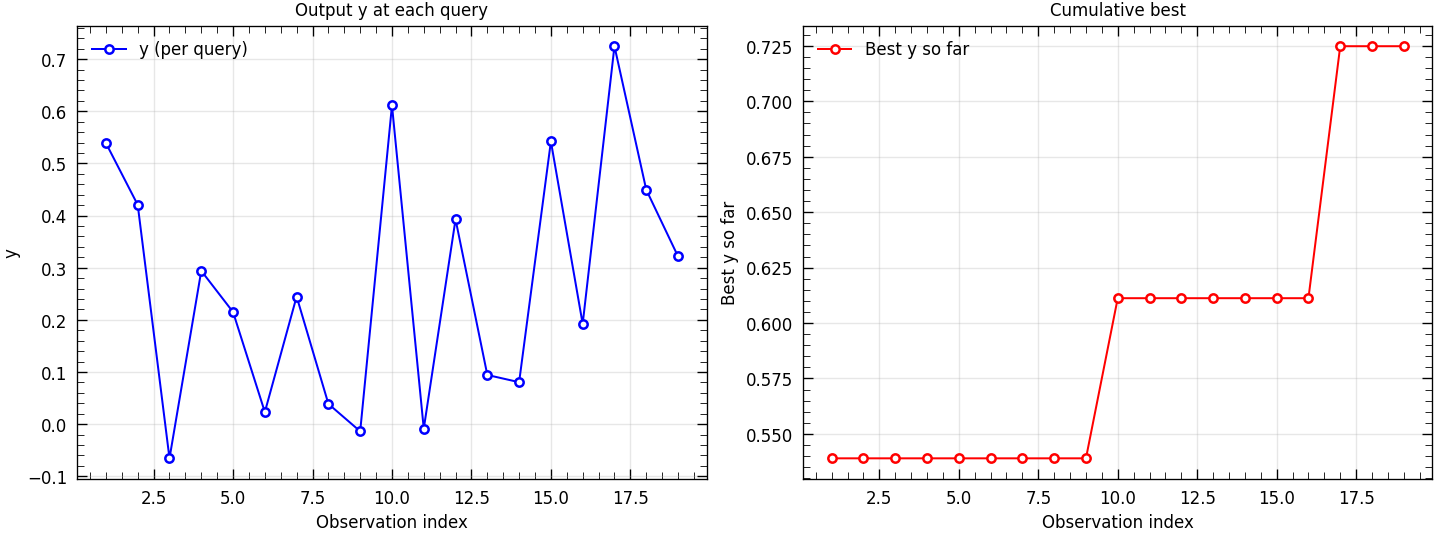

In [74]:
# Convergence: y per query (left) and running best (right)
n_obs = len(y)
obs_idx = np.arange(1, n_obs + 1, dtype=float)
best_so_far = np.maximum.accumulate(y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=F2_FIG_1X2_LINE)
ax1.plot(obs_idx, y, 'o-', color='blue', markersize=5, markerfacecolor='w', markeredgecolor='b', markeredgewidth=1.5, label='y (per query)')
ax1.set_xlabel('Observation index')
ax1.set_ylabel('y')
ax1.set_title('Output y at each query')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(obs_idx, best_so_far, 'o-', color='red', markersize=5, markerfacecolor='w', markeredgecolor='r', markeredgewidth=1.5, label='Best y so far')
ax2.set_xlabel('Observation index')
ax2.set_ylabel('Best y so far')
ax2.set_title('Cumulative best')
ax2.legend()
ax2.grid(True, alpha=0.3)
if IF_SHOW_PLOT:
    plt.show()


## 2. Visualize the points

`X` shape (n, 2): x_1 = `X[:, 0]`, x_2 = `X[:, 1]`. 2D: horizontal = x_1, vertical = x_2; 3D: floor = (x_1, x_2), height = y.

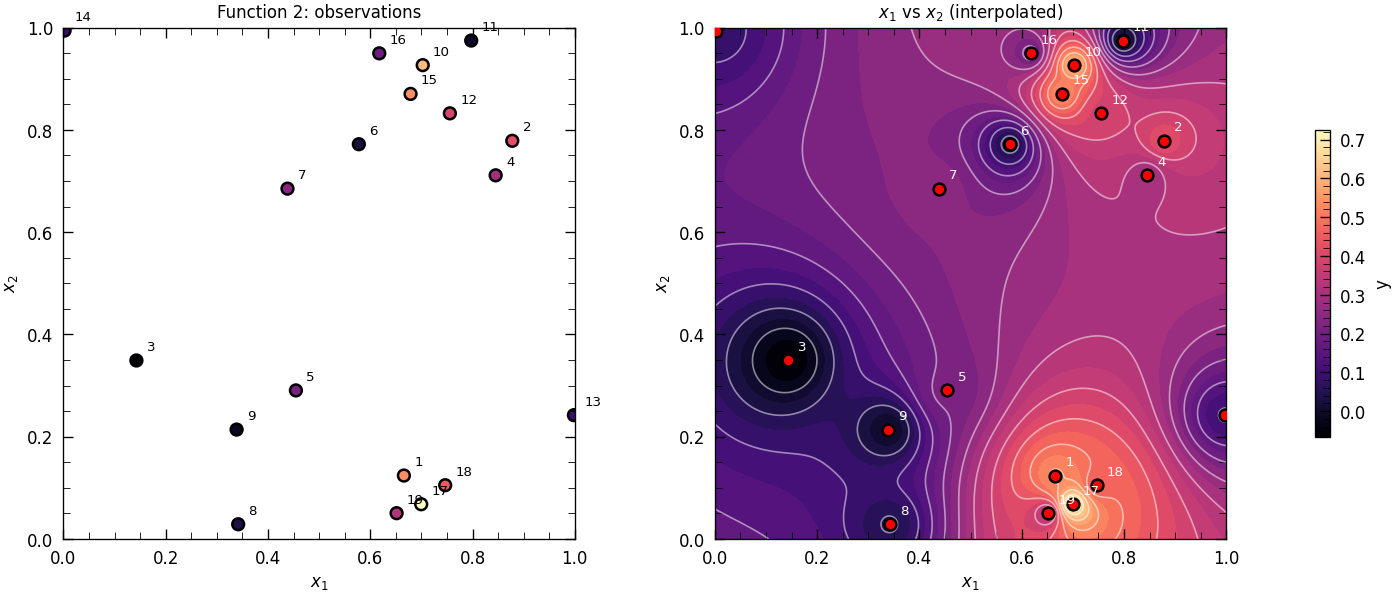

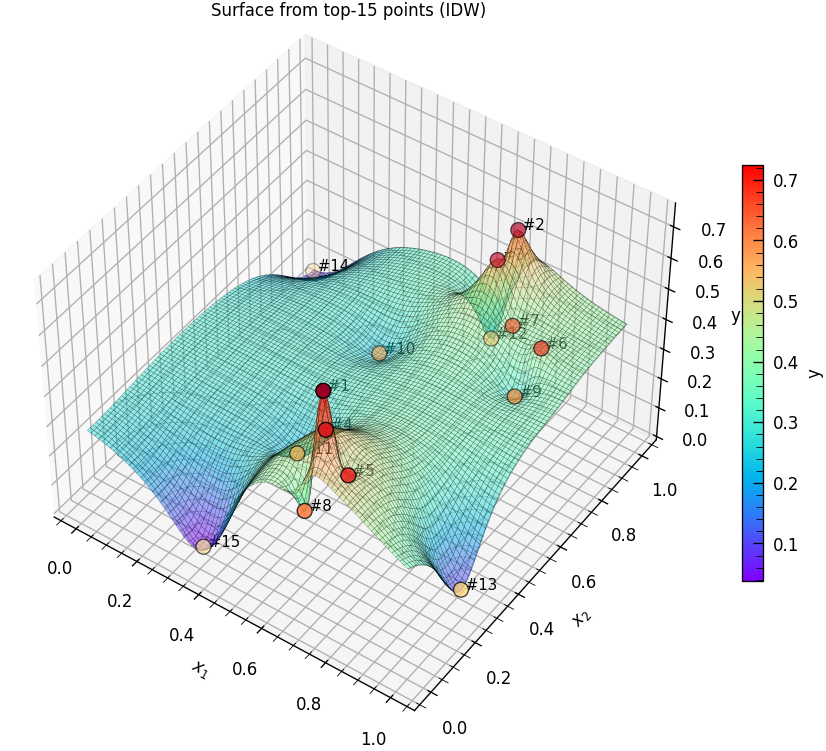

In [75]:
# ==== Evaluation grid + IDW interpolation ====
x1g = np.linspace(0, 1, n_grid)
x2g = np.linspace(0, 1, n_grid)
X1g, X2g = np.meshgrid(x1g, x2g)
grid_pts = np.column_stack([X1g.ravel(), X2g.ravel()])
candidate_pts = sample_candidates(n_cand, 2, method=CANDIDATE_SAMPLING_METHOD, seed=42)
dist_gx = np.sqrt(((grid_pts[:, None, :] - X[None, :, :]) ** 2).sum(axis=2)) + 1e-12
w = 1.0 / (dist_gx ** 2)
Y_grid = ((w * y[None, :]).sum(axis=1) / w.sum(axis=1)).reshape(X1g.shape)

# ====  PLOTS  ====

# --- 2D plots: scatter (left) + interpolated contour (right) ---
# Shared color scale for both panels (F3-style)
_idw_min = min(Y_grid.min(), y.min())
_idw_max = max(Y_grid.max(), y.max())
if _idw_max <= _idw_min:
    _idw_max = _idw_min + 1e-10
_idw_levels = np.linspace(_idw_min, _idw_max, CONTOURF_LEVELS)
_idw_norm = plt.Normalize(_idw_min, _idw_max)
try:
    _idw_symlog = (WARP_LABEL != "None")
except NameError:
    _idw_symlog = False
# Norm for left scatter from observation y so points span the colormap (grid norm can make them all black)
import matplotlib.colors as mcolors
_y_flat = np.asarray(y).ravel()
_y_f = _y_flat[np.isfinite(_y_flat)]
if _y_f.size > 0:
    _ymin, _ymax = float(np.min(_y_f)), float(np.max(_y_f))
    if _idw_symlog and (_ymax > 0 or _ymin < 0):
        _scale = max(abs(_ymin), abs(_ymax), 1e-30)
        _sig = _y_f[np.abs(_y_f) > _scale * 1e-8]
        _linthresh = float(np.percentile(np.abs(_sig), 10)) if len(_sig) > 0 else _scale * 1e-4
        _linthresh = max(_linthresh, 1e-30)
        y_scatter_norm = mcolors.SymLogNorm(linthresh=_linthresh, vmin=_ymin, vmax=_ymax)
    else:
        y_scatter_norm = mcolors.Normalize(vmin=_ymin, vmax=_ymax)
else:
    y_scatter_norm = _idw_norm

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=F2_FIG_1X2)

# --- left plot: scatter colored by y (F3-style observations panel)
sc = ax1.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap="magma", norm=y_scatter_norm, edgecolors="k", linewidths=SCATTER_EDGE_LW)
for i in range(len(y)):
    ax1.text(X[i, 0] + 0.02, X[i, 1] + 0.02, str(i + 1), fontsize=8, zorder=10)
ax1.set_xlabel(r"$x_1$"); ax1.set_ylabel(r"$x_2$")
ax1.set_title("Function 2: observations"); ax1.set_aspect("equal")
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)

# --- right plot: IDW contour + observations (F3-style: red markers on contour)
cf = ax2.contourf(X1g, X2g, Y_grid, levels=_idw_levels, norm=_idw_norm, cmap="magma")
ax2.contour(X1g, X2g, Y_grid, levels=_idw_levels[::max(1, len(_idw_levels)//CONTOUR_LINE_LEVELS)], colors="white", linewidths=CONTOUR_LINEWIDTH, linestyles='-', alpha=CONTOUR_ALPHA)
ax2.scatter(X[:, 0], X[:, 1], c='red', s=50, edgecolors="k", linewidths=SCATTER_EDGE_LW, zorder=5)
for i in range(len(y)):
    ax2.text(X[i, 0] + 0.02, X[i, 1] + 0.02, str(i + 1), fontsize=8, color="white", zorder=10)
ax2.set_xlabel(r"$x_1$"); ax2.set_ylabel(r"$x_2$")
ax2.set_title(r"$x_1$ vs $x_2$ (interpolated)")
ax2.set_aspect("equal"); ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)

# Shared colorbar (F3-style ScalarMappable)
sm = plt.cm.ScalarMappable(norm=_idw_norm, cmap="magma")
sm.set_array(y)
cbar = fig.colorbar(sm, ax=[ax1, ax2], shrink=0.6, label="y")

if IF_EXPORT_PLOT:
    out_dir = PLOT_EXPORT_DIR
    assert_not_under_initial_data(out_dir, project_root=repo_root)
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / "function_2_observations.png", dpi=150)
    print("Plot saved.")
if IF_SHOW_PLOT:
    plt.show()

# ==== Top candidate regions ====
TOP_N = 15
N_TOP = min(TOP_N, len(y))
top_idx   = np.argsort(y)[::-1][:N_TOP]   # indices sorted best → worst
top_ranks = np.arange(1, N_TOP + 1)        # 1 = best
top_X, top_y = X[top_idx], y[top_idx]

# Marker size and colour scale: rank 1 is largest/brightest
sizes  = np.linspace(280, 60, N_TOP)
colors = plt.cm.YlOrRd_r(np.linspace(0.05, 0.85, N_TOP))

# ==== 3D contour surface built from top-10 points only ====
VIEW_ELEV = 45   # elevation angle (deg)
VIEW_AZIM = -55   # azimuth / rotation angle (deg)

dist_top = np.sqrt(((grid_pts[:, None, :] - top_X[None, :, :]) ** 2).sum(axis=2)) + 1e-12
w_top = 1.0 / (dist_top ** 2)
Y_top10 = ((w_top * top_y[None, :]).sum(axis=1) / w_top.sum(axis=1)).reshape(X1g.shape)
stride = max(1, n_grid // 80)

fig4 = plt.figure(figsize=F2_FIG_3D)
ax3d = fig4.add_subplot(111, projection="3d")
surf = ax3d.plot_surface(X1g, X2g, Y_top10, rstride=stride, cstride=stride, cmap="rainbow", alpha=0.5, edgecolor="black", linewidth=0.2)
ax3d.contour(X1g, X2g, Y_top10, levels=30, colors="k", linewidths=0.3, alpha=0.5)
ax3d.scatter(top_X[:, 0], top_X[:, 1], top_y, c=colors, s=80, edgecolors="k", linewidths=0.8, depthshade=True)
norm = plt.Normalize(Y_top10.min(), Y_top10.max())
sm = plt.cm.ScalarMappable(cmap=plt.cm.rainbow, norm=norm)
sm.set_array(Y_top10)
fig4.colorbar(sm, ax=ax3d, shrink=0.6).set_label("y")

for i in range(N_TOP):
    ax3d.text(top_X[i, 0], top_X[i, 1], top_y[i], f" #{top_ranks[i]}", fontsize=9, ha="left")
ax3d.set_xlabel(r"$x_1$"); ax3d.set_ylabel(r"$x_2$"); ax3d.set_zlabel("y")
ax3d.set_title(f"Surface from top-{N_TOP} points (IDW)")
ax3d.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)

if IF_EXPORT_PLOT:
    out_dir = PLOT_EXPORT_DIR
    assert_not_under_initial_data(out_dir, project_root=repo_root)
    out_dir.mkdir(parents=True, exist_ok=True)
    fig4.savefig(out_dir / "function_2_3d_top_points.png", dpi=150)
    print("3D plot saved.")
if IF_SHOW_PLOT:
    plt.show()


## 3. Suggest next point to submit, using Bayesian Optimization Methodology

### 3.1 Surrogate: GP kernels

We use three kernels: **RBF** (smooth), **Matérn (ν=1.5)** (rougher), **RBF + WhiteKernel** (adds observation noise). Each gives a different prior and uncertainty estimate.


In [76]:
# ==== Build and fit three GP kernels on (X, y) ====
# RBF: smooth isotropic  |  Matern: rougher  |  RBF+White: with explicit noise
# OPTIMIZE_KERNEL=False → fixed hyperparameters (optimizer=None); True → MLE with 5 restarts.
_gp_optimizer = None if not OPTIMIZE_KERNEL else 'fmin_l_bfgs_b'
_gp_n_restarts = N_RESTARTS_KERNEL if OPTIMIZE_KERNEL else 0
kernel_RBF       = ConstantKernel(CONSTANT_KERNEL_SCALE, constant_value_bounds=CONSTANT_SCALE_BOUNDS) * RBF(length_scale=LENGTH_SCALE, length_scale_bounds=LENGTH_SCALE_BOUNDS)
kernel_Matern    = ConstantKernel(CONSTANT_KERNEL_SCALE, constant_value_bounds=CONSTANT_SCALE_BOUNDS) * Matern(length_scale=LENGTH_SCALE, nu=MATERN_NU, length_scale_bounds=LENGTH_SCALE_BOUNDS)
kernel_RBF_noise = ConstantKernel(CONSTANT_KERNEL_SCALE, constant_value_bounds=CONSTANT_SCALE_BOUNDS) * RBF(length_scale=LENGTH_SCALE, length_scale_bounds=LENGTH_SCALE_BOUNDS) + WhiteKernel(noise_level=WHITE_NOISE_LEVEL, noise_level_bounds=WHITE_NOISE_BOUNDS)

gp_RBF       = GaussianProcessRegressor(kernel=kernel_RBF,       alpha=GP_ALPHA, optimizer=_gp_optimizer, n_restarts_optimizer=_gp_n_restarts, normalize_y=True)
gp_Matern    = GaussianProcessRegressor(kernel=kernel_Matern,    alpha=GP_ALPHA, optimizer=_gp_optimizer, n_restarts_optimizer=_gp_n_restarts, normalize_y=True)
gp_RBF_noise = GaussianProcessRegressor(kernel=kernel_RBF_noise, alpha=GP_ALPHA, optimizer=_gp_optimizer, n_restarts_optimizer=_gp_n_restarts, normalize_y=True)

gp_RBF.fit(X, y); gp_Matern.fit(X, y); gp_RBF_noise.fit(X, y)
print(f"Kernel hyperparameters: {'optimized (MLE)' if OPTIMIZE_KERNEL else 'fixed (no optimization)'}")

# Posterior μ and σ on the visualization grid (reshaped for contour plots)
mu_gp_RBF,       sigma_gp_RBF       = gp_RBF.predict(grid_pts,        return_std=True)
mu_gp_Matern,    sigma_gp_Matern    = gp_Matern.predict(grid_pts,     return_std=True)
mu_gp_RBF_noise, sigma_gp_RBF_noise = gp_RBF_noise.predict(grid_pts,  return_std=True)
mu_gp_RBF,    sigma_gp_RBF    = mu_gp_RBF.reshape(X1g.shape),    sigma_gp_RBF.reshape(X1g.shape)
mu_gp_Matern, sigma_gp_Matern = mu_gp_Matern.reshape(X1g.shape), sigma_gp_Matern.reshape(X1g.shape)
mu_gp_RBF_noise, sigma_gp_RBF_noise = mu_gp_RBF_noise.reshape(X1g.shape), sigma_gp_RBF_noise.reshape(X1g.shape)

# Posterior on candidate_pts (for acquisition)
mu_cand_RBF,    sigma_cand_RBF    = gp_RBF.predict(candidate_pts,    return_std=True)
mu_cand_Matern, sigma_cand_Matern = gp_Matern.predict(candidate_pts, return_std=True)

# Aux GPs on −y: skopt acquisition assumes minimization, so argmax acq on −y ≡ argmax y
gp_neg_RBF, gp_neg_Matern = copy.deepcopy(gp_RBF), copy.deepcopy(gp_Matern)
gp_neg_RBF_noise = copy.deepcopy(gp_RBF_noise)
gp_neg_RBF.fit(X, -y); gp_neg_Matern.fit(X, -y); gp_neg_RBF_noise.fit(X, -y)

print(f"GP RBF kernel:    {gp_RBF.kernel_}")
print(f"GP Matern kernel: {gp_Matern.kernel_}")


Kernel hyperparameters: optimized (MLE)
GP RBF kernel:    0.957**2 * RBF(length_scale=0.0435)
GP Matern kernel: 0.961**2 * Matern(length_scale=0.0484, nu=1.5)


In [77]:
# ==== Kernel selection: LML (auto) or user choice (RBF, Matern, etc.) ====
# GP_KERNEL = None or "none" → auto-select by log-marginal-likelihood (LML).
# GP_KERNEL = "RBF" | "Matern" | "RBF + WhiteKernel" (or common variants) → use that kernel.

gps = [
    (gp_RBF,       gp_neg_RBF,       "RBF"),
    (gp_Matern,    gp_neg_Matern,    "Matérn (ν=1.5)"),
    (gp_RBF_noise, gp_neg_RBF_noise, "RBF + WhiteKernel"),
]
CANONICAL_NAMES = ["RBF", "Matérn (ν=1.5)", "RBF + WhiteKernel"]
KERNEL_ALIASES = {
    "rbf": "RBF",
    "matern": "Matérn (ν=1.5)",
    "matérn (ν=1.5)": "Matérn (ν=1.5)",
    "matern (ν=1.5)": "Matérn (ν=1.5)",
    "rbf + whitekernel": "RBF + WhiteKernel",
    "rbf+whitekernel": "RBF + WhiteKernel",
    "rbf + white": "RBF + WhiteKernel",
    "white": "RBF + WhiteKernel",
}

def _normalize_kernel_input(val):
    if val is None:
        return None
    s = str(val).strip()
    if s.lower() in ("none", ""):
        return None
    return s

def _resolve_kernel_name(user_input):
    if user_input is None:
        return None
    key = user_input.lower().strip()
    if key in KERNEL_ALIASES:
        return KERNEL_ALIASES[key]
    if user_input in CANONICAL_NAMES:
        return user_input
    for c in CANONICAL_NAMES:
        if c.lower() == key or key in c.lower():
            return c
    return None

use_lml = _normalize_kernel_input(GP_KERNEL) is None

if use_lml:
    print(75*"=")
    print("Kernel selection via log-marginal-likelihood (LML)")
    print(75*"=")
    lml_scores = {name: gp.log_marginal_likelihood_value_ for gp, _, name in gps}
    best_name  = max(lml_scores, key=lml_scores.get)
    print("Log-marginal-likelihood per kernel:")
    for name, lml in lml_scores.items():
        marker = "  ← best" if name == best_name else ""
        print(f"  {name:<22}: {lml:.4f}{marker}")
    print(f"\nAuto-selected kernel: {best_name}")
else:
    resolved = _resolve_kernel_name(_normalize_kernel_input(GP_KERNEL))
    if resolved is None:
        print(f"Unknown kernel '{GP_KERNEL}'. Choose from: {CANONICAL_NAMES}. Falling back to LML.")
        lml_scores = {name: gp.log_marginal_likelihood_value_ for gp, _, name in gps}
        best_name = max(lml_scores, key=lml_scores.get)
    else:
        best_name = resolved
        print(75*"=")
        print(f"Kernel selection by user: {best_name}")
        print(75*"=")

best_gp     = next(gp  for gp, _, name in gps if name == best_name)
best_gp_neg = next(gn  for _,  gn, name in gps if name == best_name and gn is not None)
print(f"  Fitted kernel: {best_gp.kernel_}")
print(75*"=")


Kernel selection via log-marginal-likelihood (LML)
Log-marginal-likelihood per kernel:
  RBF                   : -25.6993
  Matérn (ν=1.5)        : -25.7980
  RBF + WhiteKernel     : -25.6913  ← best

Auto-selected kernel: RBF + WhiteKernel
  Fitted kernel: 0.899**2 * RBF(length_scale=0.0466) + WhiteKernel(noise_level=0.107)


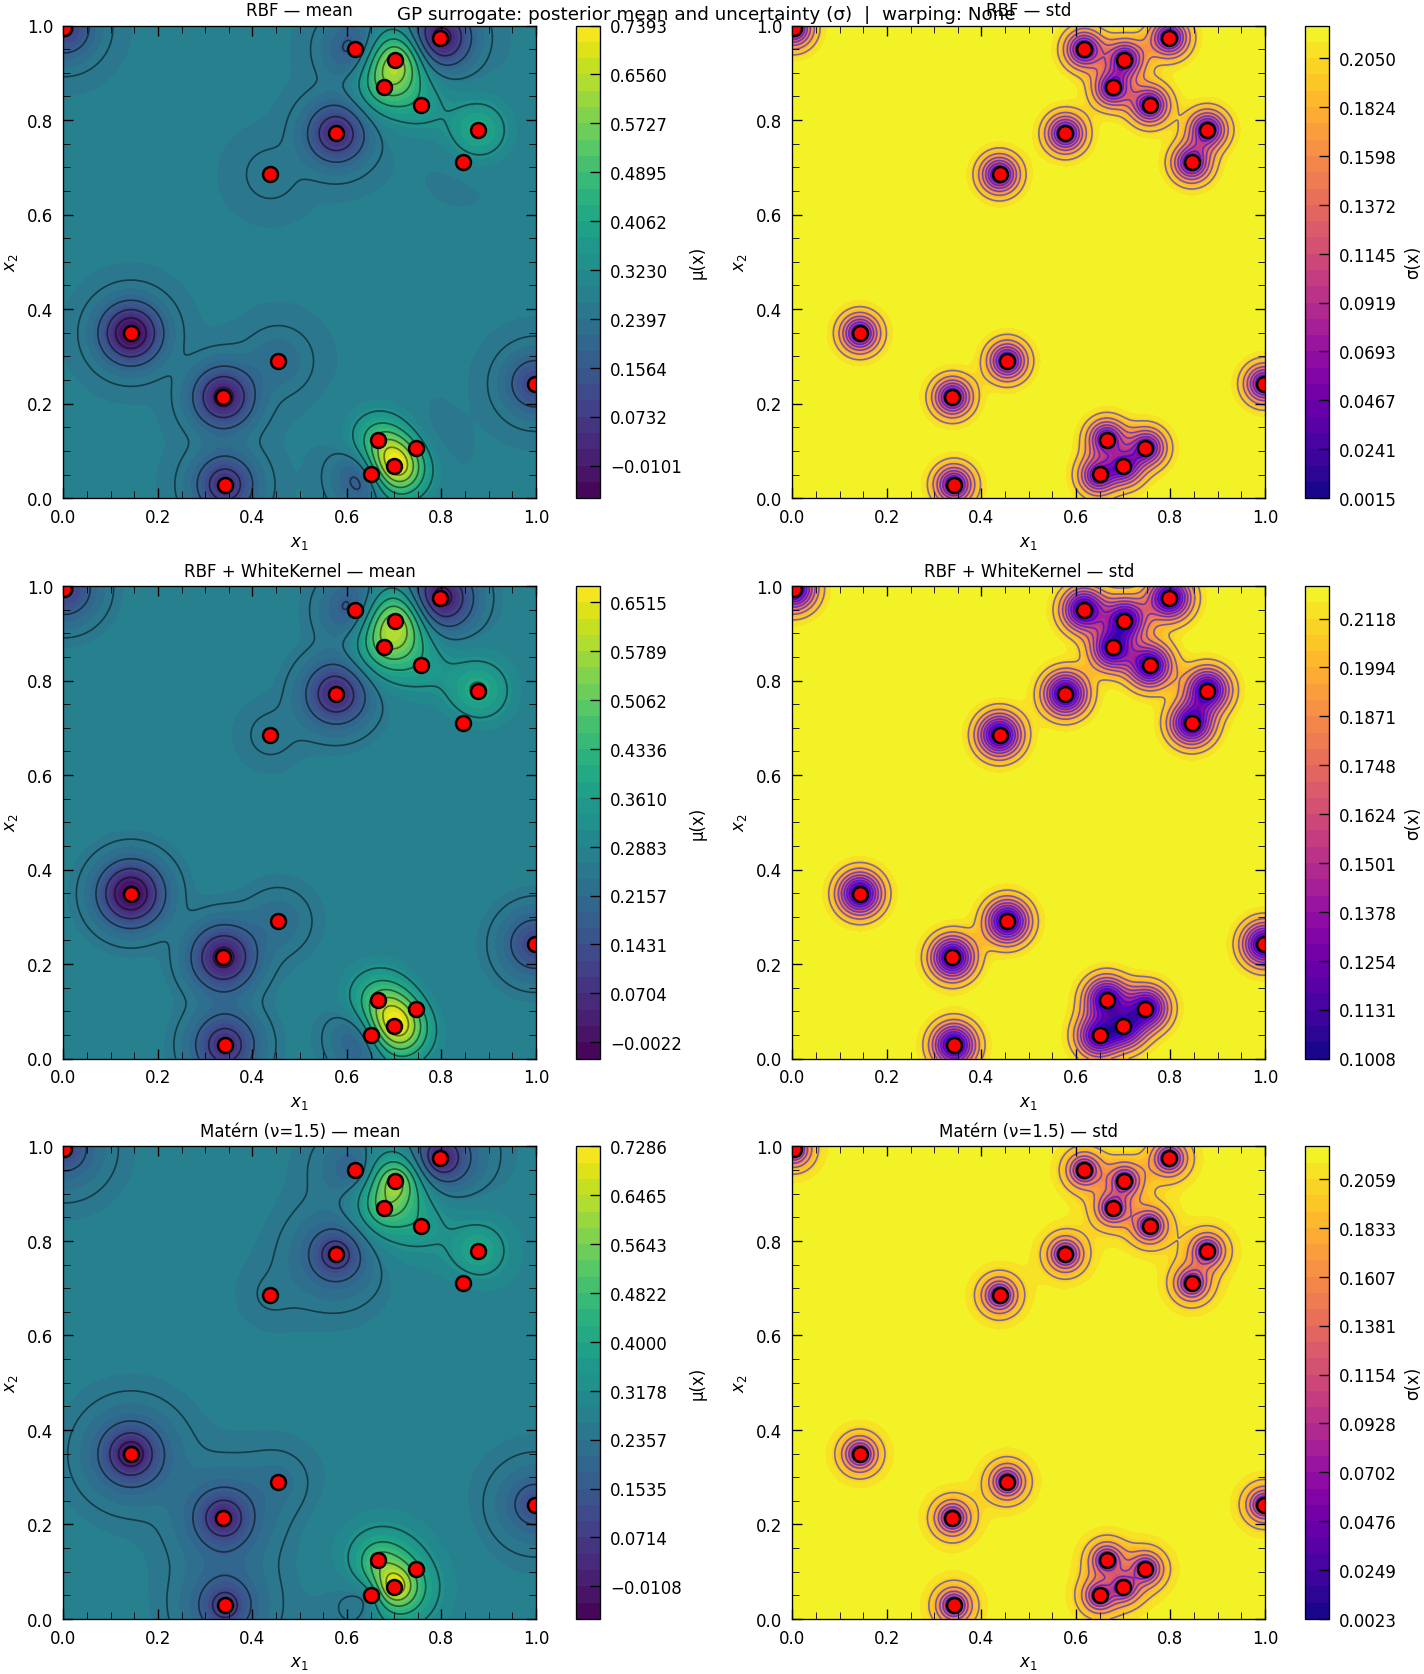

In [78]:
# GP posterior: mean (left) and std (right) for each kernel — shared colour scale per column
kernels_info = [
    (mu_gp_RBF,       sigma_gp_RBF,       "RBF"),
    (mu_gp_RBF_noise, sigma_gp_RBF_noise, "RBF + WhiteKernel"),
    (mu_gp_Matern,    sigma_gp_Matern,    "Matérn (ν=1.5)"),
]

fig, axes = plt.subplots(3, 2, figsize=F2_FIG_3X2)
for i, (mu, sig, name) in enumerate(kernels_info):
    ax_mu, ax_sig = axes[i, 0], axes[i, 1]
    # Data-driven levels so small variation is visible (avoids single-colour when RBF is nearly flat)
    _mu_min, _mu_max = np.nanmin(mu), np.nanmax(mu)
    _sig_min, _sig_max = np.nanmin(sig), np.nanmax(sig)
    if _mu_max <= _mu_min: _mu_max = _mu_min + 1e-10
    if _sig_max <= _sig_min: _sig_max = _sig_min + 1e-10
    levels_mu = np.linspace(_mu_min, _mu_max, CONTOURF_LEVELS)
    levels_sig = np.linspace(_sig_min, _sig_max, CONTOURF_LEVELS)

    # Mean panel
    cf1 = ax_mu.contourf(X1g, X2g, mu, levels=levels_mu, cmap="viridis")
    ax_mu.contour(X1g, X2g, mu, levels=np.linspace(_mu_min, _mu_max, CONTOUR_LINE_LEVELS), colors="k", linewidths=CONTOUR_LINEWIDTH, alpha=CONTOUR_ALPHA, linestyles=CONTOUR_LINESTYLE)
    fig.colorbar(cf1, ax=ax_mu).set_label("μ(x)")
    ax_mu.scatter(X[:, 0], X[:, 1], c="red", s=80, edgecolors="k", zorder=2, linewidths=1.5)
    ax_mu.set_xlabel(r"$x_1$"); ax_mu.set_ylabel(r"$x_2$")
    ax_mu.set_title(f"{name} — mean")
    ax_mu.set_aspect("equal")

    # Std panel
    cf2 = ax_sig.contourf(X1g, X2g, sig, levels=levels_sig, cmap="plasma")
    ax_sig.contour(X1g, X2g, sig, levels=np.linspace(_sig_min, _sig_max, CONTOUR_LINE_LEVELS), colors="blue", linewidths=CONTOUR_LINEWIDTH, alpha=CONTOUR_ALPHA, linestyles=CONTOUR_LINESTYLE)
    fig.colorbar(cf2, ax=ax_sig).set_label("σ(x)")
    ax_sig.scatter(X[:, 0], X[:, 1], c="red", s=80, edgecolors="k", zorder=2, linewidths=1.5)
    ax_sig.set_xlabel(r"$x_1$"); ax_sig.set_ylabel(r"$x_2$")
    ax_sig.set_title(f"{name} — std")
    ax_sig.set_aspect("equal")

fig.suptitle(f"GP surrogate: posterior mean and uncertainty (σ)  |  warping: {WARP_LABEL}", y=0.995)
if IF_EXPORT_PLOT:
    out_dir = PLOT_EXPORT_DIR
    assert_not_under_initial_data(out_dir, project_root=repo_root)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / "function_2_gp_three_kernels.png"
    fig.savefig(out_path, dpi=150, format="png", bbox_inches="tight")
    print("Plot saved to", out_path)
if IF_SHOW_PLOT:
    plt.show()


### 3.2 Acquisition functions

EI (Expected Improvement), UCB (Upper Confidence Bound), PI (Probability of Improvement).


In [79]:
# ==== Acquisition functions (skopt, on −y GPs) ====
y_best = best_y

# EI: E[max(f(x) − f(x⁺), 0)]
EI_RBF          = gaussian_ei(candidate_pts, gp_neg_RBF,       y_opt=-y_best, xi=XI_EI_PI)
EI_RBF_noise    = gaussian_ei(candidate_pts, gp_neg_RBF_noise, y_opt=-y_best, xi=XI_EI_PI)
EI_Matern       = gaussian_ei(candidate_pts, gp_neg_Matern,     y_opt=-y_best, xi=XI_EI_PI)
# PI: P(f(x) > f(x⁺) + ξ)
PI_RBF          = gaussian_pi(candidate_pts, gp_neg_RBF,       y_opt=-y_best, xi=XI_EI_PI)
PI_RBF_noise    = gaussian_pi(candidate_pts, gp_neg_RBF_noise,  y_opt=-y_best, xi=XI_EI_PI)
PI_Matern       = gaussian_pi(candidate_pts, gp_neg_Matern,     y_opt=-y_best, xi=XI_EI_PI)

# LCB: minimize μ(x) − κσ(x) on −y ≡ maximize UCB of y
LCB_RBF         = gaussian_lcb(candidate_pts, gp_neg_RBF,       kappa=KAPPA_UCB)
LCB_RBF_noise   = gaussian_lcb(candidate_pts, gp_neg_RBF_noise,  kappa=KAPPA_UCB)
LCB_Matern      = gaussian_lcb(candidate_pts, gp_neg_Matern,     kappa=KAPPA_UCB)

# Mask candidates too close to existing observations (avoid re-evaluating)
min_dist_cand = np.min(np.sqrt(((candidate_pts[:, None, :] - X[None, :, :]) ** 2).sum(axis=2)), axis=1)
next_x_high_dist = np.clip(np.asarray(candidate_pts[np.argmax(min_dist_cand)]).ravel(), 0.0, 0.999999)
too_close = min_dist_cand < MIN_DIST_THRESHOLD
try: BOUNDARY_MARGIN
except NameError: BOUNDARY_MARGIN = 0
# Optional: mask candidates near domain boundaries (low-d only; set BOUNDARY_MARGIN=0 for high-d)
near_boundary = np.any((candidate_pts <= BOUNDARY_MARGIN) | (candidate_pts >= 1.0 - BOUNDARY_MARGIN), axis=1) if BOUNDARY_MARGIN > 0 else np.zeros(len(candidate_pts), dtype=bool)
masked = too_close | near_boundary
EI_RBF[masked] = EI_RBF_noise[masked] = EI_Matern[masked] = -np.inf
PI_RBF[masked] = PI_RBF_noise[masked] = PI_Matern[masked] = -np.inf
LCB_RBF[masked] = LCB_RBF_noise[masked] = LCB_Matern[masked] = np.inf

def _pick(acq_val, maximize, fallback):
    idx = np.argmax(acq_val) if maximize else np.argmin(acq_val)
    return np.asarray(fallback).ravel() if masked[idx] else candidate_pts[idx]

x_best_EI_RBF        = _pick(EI_RBF, True, next_x_high_dist)
x_best_EI_RBF_noise  = _pick(EI_RBF_noise, True, next_x_high_dist)
x_best_EI_Matern     = _pick(EI_Matern, True, next_x_high_dist)
x_best_PI_RBF        = _pick(PI_RBF, True, next_x_high_dist)
x_best_PI_RBF_noise  = _pick(PI_RBF_noise, True, next_x_high_dist)
x_best_PI_Matern     = _pick(PI_Matern, True, next_x_high_dist)
x_best_UCB_RBF        = _pick(LCB_RBF, False, next_x_high_dist)
x_best_UCB_RBF_noise  = _pick(LCB_RBF_noise, False, next_x_high_dist)
x_best_UCB_Matern     = _pick(LCB_Matern, False, next_x_high_dist)

# Argmax from selected kernel
is_rbf    = (best_name == "RBF")
is_rbf_w  = (best_name == "RBF + WhiteKernel")
is_matern = (best_name == "Matérn (ν=1.5)" or "Matérn" in best_name)
x_best_EI  = x_best_EI_RBF if is_rbf else (x_best_EI_RBF_noise if is_rbf_w else x_best_EI_Matern)
x_best_PI  = x_best_PI_RBF if is_rbf else (x_best_PI_RBF_noise if is_rbf_w else x_best_PI_Matern)
x_best_UCB = x_best_UCB_RBF if is_rbf else (x_best_UCB_RBF_noise if is_rbf_w else x_best_UCB_Matern)

print(f"EI  (RBF):   next = ({x_best_EI_RBF[0]:.3f}, {x_best_EI_RBF[1]:.3f})")
print(f"EI  (best={best_name}): ({x_best_EI[0]:.3f}, {x_best_EI[1]:.3f})")
print(f"Best y so far: {y_best:.4g}")


EI  (RBF):   next = (0.747, 0.050)
EI  (best=RBF + WhiteKernel): (0.747, 0.050)
Best y so far: 0.7248


### 3.3 Acquisition function surfaces

EI and UCB heatmaps over the full grid — shows *where* each strategy wants to query, not just the argmax point.

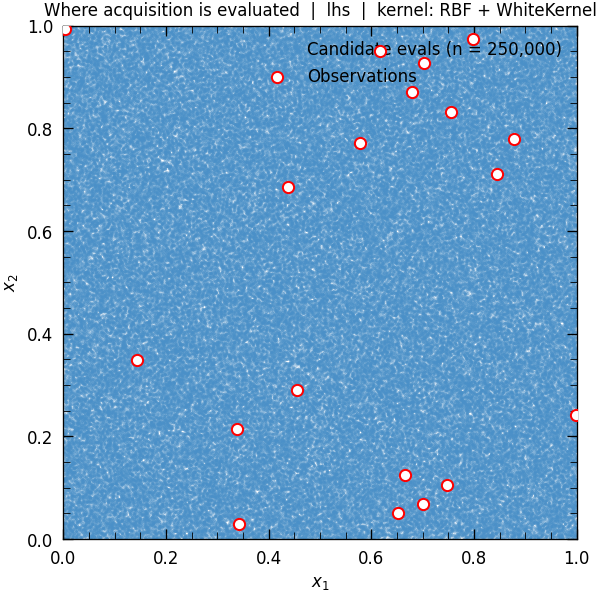

In [80]:
############################################################
# Acquisition: candidate pool (where EI / PI / UCB are evaluated for argmax)
############################################################

_cand_xy = np.asarray(candidate_pts, dtype=float).reshape(-1, 2)
_n_pool = len(_cand_xy)
_cand_show = _cand_xy
_cand_note = f"n = {_n_pool:,}"

fig_cand, ax_cand = plt.subplots(1, 1, figsize=(F2_FIG_1X2[0] / 2, F2_FIG_1X2[1]))
ax_cand.scatter(
    _cand_show[:, 0], _cand_show[:, 1],
    s=3, c="#4a90c8", alpha=0.35, linewidths=0, rasterized=True,
    label=f"Candidate evals ({_cand_note})",
)
ax_cand.scatter(X[:, 0], X[:, 1], c="white", s=45, edgecolors="red", zorder=6, linewidths=1.2, label="Observations")
ax_cand.set_xlim(0, 1)
ax_cand.set_ylim(0, 1)
ax_cand.set_aspect("equal")
ax_cand.set_xlabel(r"$x_1$"); ax_cand.set_ylabel(r"$x_2$")
ax_cand.set_title(
    f"Where acquisition is evaluated  |  {CANDIDATE_SAMPLING_METHOD}  |  kernel: {best_name}"
)
ax_cand.legend(loc="upper right", framealpha=0.95)
if IF_EXPORT_PLOT:
    out_dir = PLOT_EXPORT_DIR
    assert_not_under_initial_data(out_dir, project_root=repo_root)
    out_dir.mkdir(parents=True, exist_ok=True)
    fig_cand.savefig(out_dir / "function_2_acquisition_candidate_pool.png", dpi=150, bbox_inches="tight")
if IF_SHOW_PLOT:
    plt.show()


Next query (argmax) uses candidate points sampled with: lhs
Ensemble mode: showing EI, PI, UCB heatmaps.


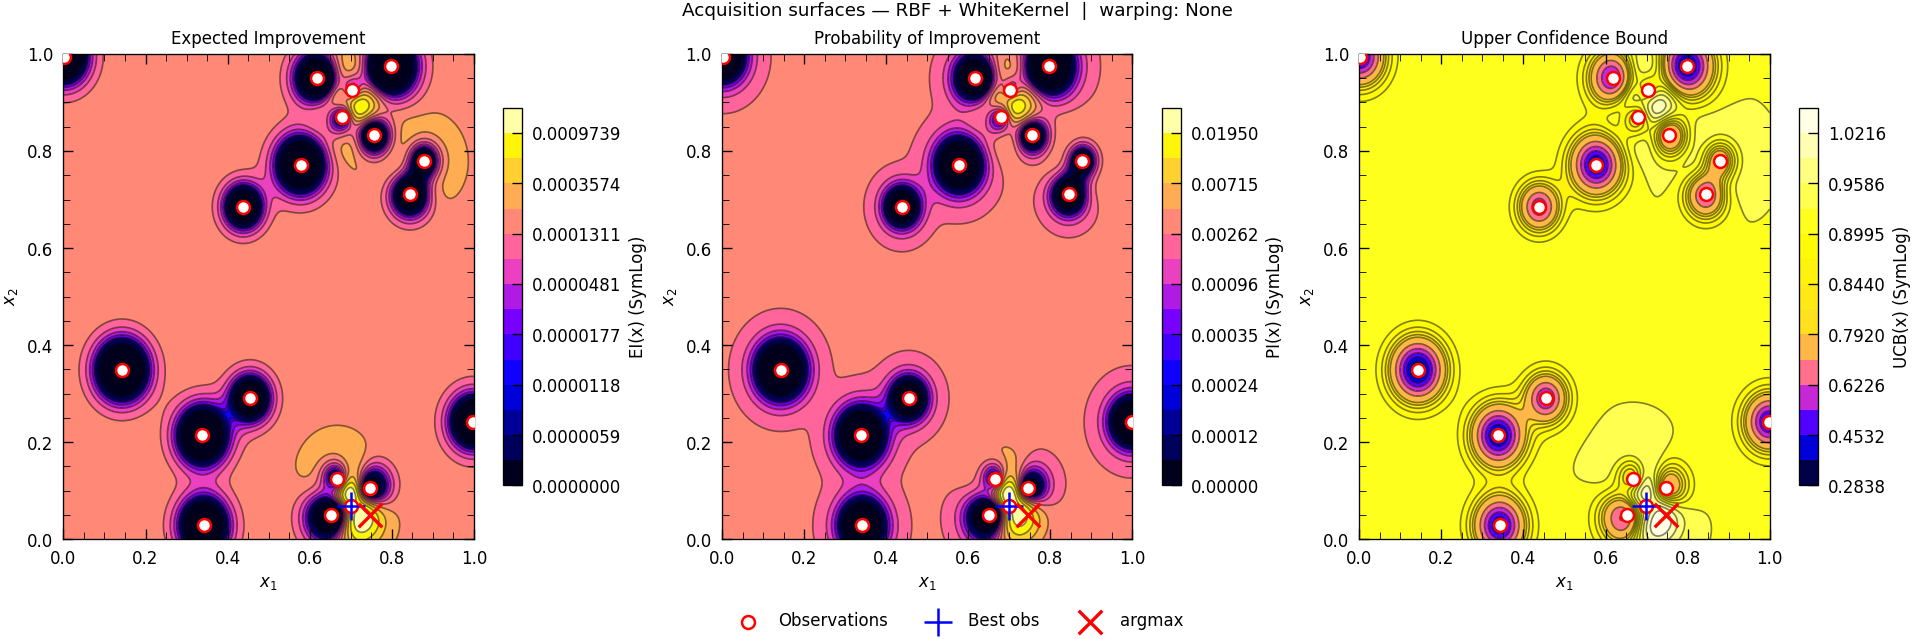

In [81]:
# ==== Acquisition surface plot(s): solo (1 panel) or ensemble (3 panels) ====
print(75*'=')
print("Next query (argmax) uses candidate points sampled with:", CANDIDATE_SAMPLING_METHOD)
if USE_ENSEMBLE:
    print("Ensemble mode: showing EI, PI, UCB heatmaps.")
else:
    print("Solo mode: showing selected acquisition:", SOLO_STRATEGY)
print(75*'=')

EI_grid  = gaussian_ei(grid_pts, best_gp_neg, y_opt=-y_best, xi=XI_EI_PI)
PI_grid  = gaussian_pi(grid_pts, best_gp_neg, y_opt=-y_best, xi=XI_EI_PI)
LCB_grid = gaussian_lcb(grid_pts, best_gp_neg, kappa=KAPPA_UCB)
UCB_grid = -LCB_grid

EI_surf  = EI_grid.reshape(X1g.shape)
PI_surf  = PI_grid.reshape(X1g.shape)
UCB_surf = UCB_grid.reshape(X1g.shape)

_acq_display = {
    "EI":  (EI_surf,  x_best_EI,  "EI(x)",  "Expected Improvement"),
    "PI":  (PI_surf,  x_best_PI,  "PI(x)",  "Probability of Improvement"),
    "UCB": (UCB_surf, x_best_UCB, "UCB(x)", "Upper Confidence Bound"),
}

if USE_ENSEMBLE:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=F2_FIG_1X3)
    for ax, surf, x_argmax, label, title in [
        (ax1, EI_surf,  x_best_EI,  "EI(x)",  "Expected Improvement"),
        (ax2, PI_surf,  x_best_PI,  "PI(x)",  "Probability of Improvement"),
        (ax3, UCB_surf, x_best_UCB, "UCB(x)", "Upper Confidence Bound"),
    ]:
        surf_plot, acq_levels, acq_norm = _prepare_surface_for_plot(surf, force_symlog=True)
        cf = ax.contourf(X1g, X2g, surf_plot, levels=acq_levels, norm=acq_norm, cmap="gnuplot2")
        ax.contour(
            X1g, X2g, surf_plot,
            levels=acq_levels[::max(1, len(acq_levels) // 11)],
            colors="k", linewidths=CONTOUR_LINEWIDTH, alpha=CONTOUR_ALPHA, linestyles=CONTOUR_LINESTYLE,
        )
        _sl = "SymLog" if hasattr(acq_norm, "linthresh") else "linear"
        fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04).set_label(f"{label} ({_sl})")
        ax.scatter(X[:, 0], X[:, 1], c="white", s=60, edgecolors="r", zorder=5, label="Observations", linewidths=1.5)
        ax.scatter(*best_x_so_far, s=300, marker="+", c="blue", linewidths=1.5, zorder=8, label="Best obs")
        ax.scatter(*x_argmax, s=200, marker="x", c="red", zorder=10, label="argmax", linewidths=2)
        ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_title(title)
    _handles_ens, _labels_ens = ax1.get_legend_handles_labels()
    fig.legend(_handles_ens, _labels_ens, loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=3, framealpha=0.95)
    fig.suptitle(f"Acquisition surfaces — {best_name}  |  warping: {WARP_LABEL}")
else:
    surf, x_argmax, cbar_label, title_name = _acq_display.get(SOLO_STRATEGY, _acq_display["EI"])
    surf_plot, acq_levels, acq_norm = _prepare_surface_for_plot(surf, force_symlog=True)
    fig, ax = plt.subplots(1, 1, figsize=F2_FIG_1X1)
    cf = ax.contourf(X1g, X2g, surf_plot, levels=acq_levels, norm=acq_norm, cmap="gnuplot2")
    ax.contour(
        X1g, X2g, surf_plot,
        levels=acq_levels[::max(1, len(acq_levels) // 11)],
        colors="k", linewidths=CONTOUR_LINEWIDTH, alpha=CONTOUR_ALPHA, linestyles=CONTOUR_LINESTYLE,
    )
    _sl = "SymLog" if hasattr(acq_norm, "linthresh") else "linear"
    fig.colorbar(cf, ax=ax).set_label(f"{cbar_label} ({_sl})")
    ax.scatter(X[:, 0], X[:, 1], c="r", s=60, edgecolors="k", zorder=5, label="Observations", linewidths=1.5)
    ax.scatter(*x_argmax, s=100, marker="x", c="red", zorder=10, label=f"Next query: argmax of {SOLO_STRATEGY} at ({x_argmax[0]:.3f}, {x_argmax[1]:.3f})", linewidths=2)
    ax.scatter(*best_x_so_far, s=300, marker="+", c="blue", linewidths=1.5, zorder=8, label="Best obs")
    ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f"{title_name} — {best_name}  |  warping: {WARP_LABEL}")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=3, framealpha=0.95)

if IF_EXPORT_PLOT:
    out_dir = PLOT_EXPORT_DIR
    assert_not_under_initial_data(out_dir, project_root=repo_root)
    out_dir.mkdir(parents=True, exist_ok=True)
    fname = "function_2_acquisition_ensemble.png" if USE_ENSEMBLE else "function_2_acquisition_surface.png"
    fig.savefig(out_dir / fname, dpi=150, bbox_inches="tight")
    print("Saved acquisition surface plot")
if IF_SHOW_PLOT:
    plt.show()


In [82]:
# Warn if posterior uncertainty is near zero (EI/PI collapse to near-zero suggestions)
sigma_max = max(np.nanmax(sigma_gp_RBF), np.nanmax(sigma_gp_Matern), np.nanmax(sigma_gp_RBF_noise))
if sigma_max < 1e-6:
    print(f"Low GP σ ({sigma_max:.2e}); EI/PI may be degenerate.")


In [83]:
# ==== Non-GP baseline suggestions (for comparison) ====
rng = np.random.default_rng(42)
best_x = best_x_so_far.copy()

# Exploit: small random step from current best
next_x_exploit = np.clip(best_x + rng.uniform(-0.1, 0.1, size=2), 0, 1)

# Explore: uniformly random point in [0, 1]²
next_x_explore = rng.uniform(0, 1, size=2)

print("Exploit:  ", next_x_exploit)
print("Explore:  ", next_x_explore)


Exploit:   [0.75449121 0.05562169]
Explore:   [0.85859792 0.69736803]


### Pairwise distances between suggestions (small = agree)

In [84]:
# Pairwise L2 distances between all suggested points (small = strategies agree)
names = ['EI', 'UCB', 'PI']
pts = [np.asarray(x).ravel() for x in [x_best_EI, x_best_UCB, x_best_PI]]
n_pts = len(pts)
dists = np.zeros((n_pts, n_pts))
for i in range(n_pts):
    for j in range(n_pts):
        dists[i, j] = np.linalg.norm(pts[i] - pts[j])
for i in range(n_pts):
    for j in range(i + 1, n_pts):
        print(f"  {names[i]} vs {names[j]}: {dists[i, j]:.4f}")
max_d = dists.max()
if max_d < AGREE_THRESHOLD:
    print(f"\n>>> Suggestions agree (max pairwise dist = {max_d:.4f} < {AGREE_THRESHOLD}).")
else:
    print(f"\n>>> Suggestions differ (max dist = {max_d:.4f}); ensemble would use centroid.")


  EI vs UCB: 0.0000
  EI vs PI: 0.0000
  UCB vs PI: 0.0000

>>> Suggestions agree (max pairwise dist = 0.0000 < 0.15).


## 4. Select next query

Ensemble: EI, PI, UCB agree → use EI; disagree → use centroid. See `docs_private/40_notes_and_references/00_bayesian_methods/ensemble_acquisition_guide.md`.

In [85]:
# ==== Section 4 — Select next query (ensemble acquisition) ====
# EI, PI, UCB: if max pairwise L2 distance < AGREE_THRESHOLD → use EI; else → centroid.
# Toggle USE_ENSEMBLE / SOLO_STRATEGY in the parameters cell above.
# Uses best kernel's argmax (x_best_EI, x_best_PI, x_best_UCB from acquisition cell).
x_EI  = np.asarray(x_best_EI).ravel()
x_PI  = np.asarray(x_best_PI).ravel()
x_UCB = np.asarray(x_best_UCB).ravel()
pts = np.array([x_EI, x_PI, x_UCB])
d12 = np.linalg.norm(pts[0] - pts[1])
d13 = np.linalg.norm(pts[0] - pts[2])
d23 = np.linalg.norm(pts[1] - pts[2])
max_d = max(d12, d13, d23)

# Without ensemble: use SOLO_STRATEGY
_solo_map = {"EI": x_EI, "PI": x_PI, "UCB": x_UCB}
next_x_no_ens = np.clip(_solo_map.get(SOLO_STRATEGY, x_EI).copy(), 0.0, 0.999999)
# With ensemble: centroid if disagree, else EI
next_x_with_ens = np.clip(np.mean(pts, axis=0), 0.0, 0.999999) if max_d >= AGREE_THRESHOLD else np.clip(x_EI.copy(), 0.0, 0.999999)

print(f"Without ensemble ({SOLO_STRATEGY}):  x = ({next_x_no_ens[0]:.4f}, {next_x_no_ens[1]:.4f})")
print(f"With ensemble: EI=({x_EI[0]:.4f},{x_EI[1]:.4f}), PI=({x_PI[0]:.4f},{x_PI[1]:.4f}), UCB=({x_UCB[0]:.4f},{x_UCB[1]:.4f}) → max_dist={max_d:.4f}")
print(f"  → {'centroid' if max_d >= AGREE_THRESHOLD else 'all agree, EI'} = ({next_x_with_ens[0]:.4f}, {next_x_with_ens[1]:.4f})")

# Use chosen mode (USE_ENSEMBLE) for downstream
next_x = next_x_with_ens if USE_ENSEMBLE else next_x_no_ens

# Proximity check: only replace with fallback for near-duplicates (avoid submitting same point twice).
DUPLICATE_THRESHOLD = 1e-3
dist_to_obs = np.sqrt(((X - next_x) ** 2).sum(axis=1))
nearest_idx  = np.argmin(dist_to_obs)
nearest_dist = dist_to_obs[nearest_idx]
if nearest_dist < DUPLICATE_THRESHOLD:
    print(f"⚠ Proposed point is duplicate (dist={nearest_dist:.2e} to obs #{nearest_idx+1}); using high-dist fallback.")
    next_x = next_x_high_dist
elif nearest_dist < MIN_DIST_THRESHOLD:
    print(f"  (Proposed point is {nearest_dist:.4f} from obs #{nearest_idx+1} — keeping it.)")

_strat = 'ensemble' if USE_ENSEMBLE else SOLO_STRATEGY
print(f"Next query | kernel: {best_name} | strategy: {_strat} | xi={XI_EI_PI}")
print(f"  x = ({next_x[0]:.4f}, {next_x[1]:.4f})")
print(f"  Nearest existing obs: #{nearest_idx+1} at dist={nearest_dist:.4f}")
print(f"  Current best y = {best_y:.4g} at ({best_x_so_far[0]:.4f}, {best_x_so_far[1]:.4f})")


Without ensemble (UCB):  x = (0.7467, 0.0501)
With ensemble: EI=(0.7467,0.0501), PI=(0.7467,0.0501), UCB=(0.7467,0.0501) → max_dist=0.0000
  → all agree, EI = (0.7467, 0.0501)
Next query | kernel: RBF + WhiteKernel | strategy: ensemble | xi=0.15
  x = (0.7467, 0.0501)
  Nearest existing obs: #17 at dist=0.0503
  Current best y = 0.7248 at (0.6997, 0.0678)


## 5. Illustrate the locations on the proposed query

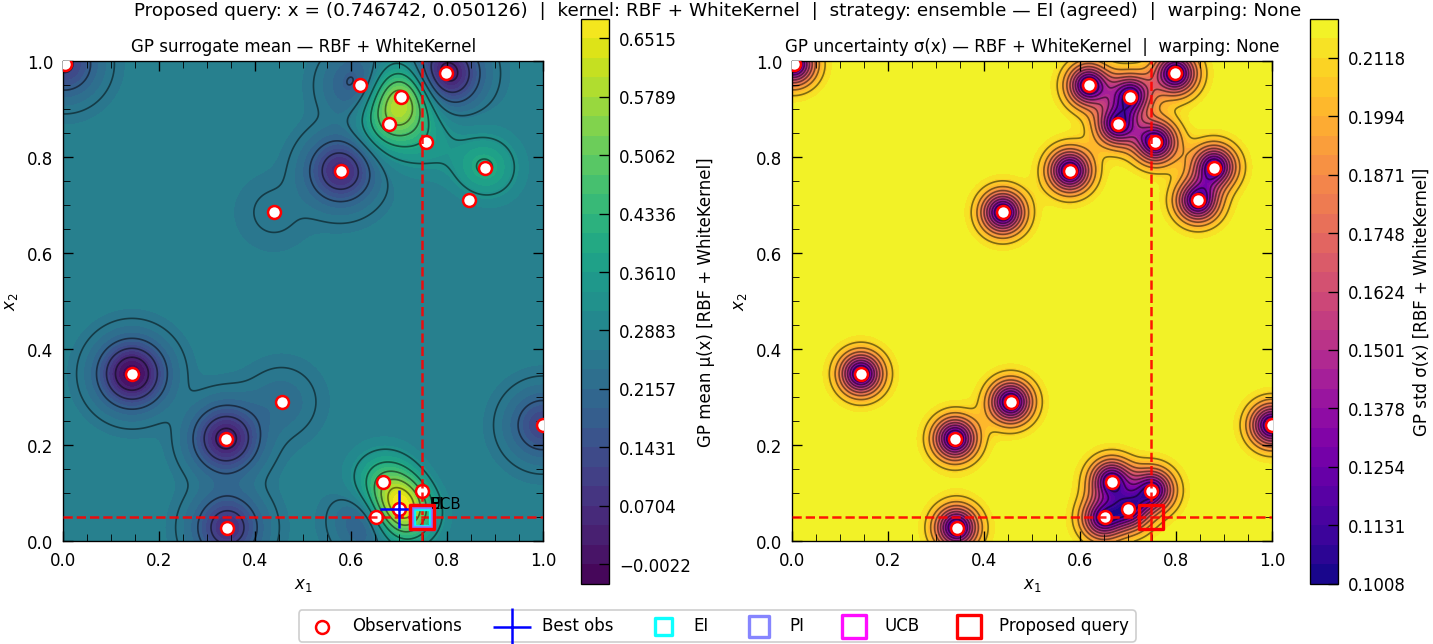

In [86]:
# ==== Summary plot: GP posterior mean (left) + GP uncertainty σ (right) ====
# Left:  GP mean μ(x) — where the surrogate predicts the objective is high.
# Right: GP std  σ(x) — where the model is uncertain (drives exploration).
# next_x (proposed query) is overlaid on both panels.

# next_x is set in Section 4 (Select next query); fallback below if that cell was skipped
try:
    _ = next_x
except NameError:
    _ei = gaussian_ei(candidate_pts, best_gp_neg, y_opt=-y_best, xi=XI_EI_PI)
    next_x = np.clip(np.asarray(candidate_pts[np.argmax(_ei)]).ravel(), 0.0, 0.999999)

_method = CANDIDATE_SAMPLING_METHOD

# Select best-kernel surfaces (already computed in GP fitting cell)
mu_best = (mu_gp_RBF if best_name == "RBF"
           else mu_gp_Matern if "Matérn" in best_name
           else mu_gp_RBF_noise)
sigma_best = (sigma_gp_RBF if best_name == "RBF"
              else sigma_gp_Matern if "Matérn" in best_name
              else sigma_gp_RBF_noise)

# Acquisition argmax points (EI, PI, UCB) for overlay
suggestions_pts = [x_best_EI, x_best_PI, x_best_UCB]
suggestions_lbl = ["EI", "PI", "UCB"]
colors_combined = plt.cm.cool(np.linspace(0, 1, len(suggestions_pts)))
markers_size = [100, 150, 200]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=F2_FIG_1X2)

# ── Left: GP posterior mean ──────────────────────────────────────────────
_mmin, _mmax = np.nanmin(mu_best), np.nanmax(mu_best)
if _mmax <= _mmin: _mmax = _mmin + 1e-10
_lev_mu = np.linspace(_mmin, _mmax, CONTOURF_LEVELS)
cf1 = ax1.contourf(X1g, X2g, mu_best, levels=_lev_mu, cmap="viridis")
ax1.contour(X1g, X2g, mu_best, levels=np.linspace(_mmin, _mmax, CONTOUR_LINE_LEVELS), colors="k", linewidths=CONTOUR_LINEWIDTH, alpha=CONTOUR_ALPHA, linestyles=CONTOUR_LINESTYLE)
fig.colorbar(cf1, ax=ax1).set_label(f"GP mean μ(x) [{best_name}]")
ax1.scatter(X[:, 0], X[:, 1], c="white", s=60, edgecolors="r", zorder=5, linewidths=1.5, label="Observations")
ax1.scatter(*best_x_so_far, s=500, marker="+", c="blue", linewidths=1.5, zorder=8, label="Best obs")
for pt, lbl, col, size in zip(suggestions_pts, suggestions_lbl, colors_combined, markers_size):
    ax1.scatter(pt[0], pt[1], s=size, marker="s", c='none', edgecolors=[col], linewidths=2.0, alpha=0.95, zorder=10, label=lbl)
    ax1.annotate(lbl, (pt[0], pt[1]), xytext=(5, 5), textcoords="offset points", fontsize=9, zorder=11)
ax1.scatter(next_x[0], next_x[1], facecolors="none", s=200, marker="s", edgecolors="red", linewidths=2, zorder=12, label="Proposed query")
ax1.axvline(next_x[0], color="r", linestyle="--", linewidth=1.5, alpha=0.9, zorder=6)
ax1.axhline(next_x[1], color="r", linestyle="--", linewidth=1.5, alpha=0.9, zorder=6)
ax1.set_xlabel(r"$x_1$"); ax1.set_ylabel(r"$x_2$")
ax1.set_title(f"GP surrogate mean — {best_name}")
ax1.set_aspect("equal")

# ── Right: GP posterior std ───────────────────────────────────────────────
_smin, _smax = np.nanmin(sigma_best), np.nanmax(sigma_best)
if _smax <= _smin: _smax = _smin + 1e-10
_lev_sig = np.linspace(_smin, _smax, CONTOURF_LEVELS)
cf2 = ax2.contourf(X1g, X2g, sigma_best, levels=_lev_sig, cmap="plasma")
ax2.contour(X1g, X2g, sigma_best, levels=np.linspace(_smin, _smax, CONTOUR_LINE_LEVELS), colors="k", linewidths=CONTOUR_LINEWIDTH, alpha=CONTOUR_ALPHA, linestyles=CONTOUR_LINESTYLE)
fig.colorbar(cf2, ax=ax2).set_label(f"GP std σ(x) [{best_name}]")
ax2.scatter(X[:, 0], X[:, 1], c="white", s=60, edgecolors="r", zorder=5, linewidths=1.5, label="Observations")
ax2.scatter(next_x[0], next_x[1], facecolors="none", s=200, marker="s", edgecolors="red", linewidths=2, zorder=12, label="Proposed query")
ax2.axvline(next_x[0], color="r", linestyle="--", linewidth=1.5, alpha=0.9, zorder=6)
ax2.axhline(next_x[1], color="r", linestyle="--", linewidth=1.5, alpha=0.9, zorder=6)
ax2.set_xlabel(r"$x_1$"); ax2.set_ylabel(r"$x_2$")
ax2.set_title(f"GP uncertainty σ(x) — {best_name}  |  warping: {WARP_LABEL}")
ax2.set_aspect("equal")

# Shared legend below both panels
handles1, labels1 = ax1.get_legend_handles_labels()
fig.legend(handles1, labels1, loc="lower center", bbox_to_anchor=(0.5, -0.06),
           ncol=LEGEND_NCOL, frameon=True, framealpha=LEGEND_FRAMEALPHA)
_strat_label = ("ensemble — centroid" if (USE_ENSEMBLE and max_d >= AGREE_THRESHOLD)
                else "ensemble — EI (agreed)" if USE_ENSEMBLE
                else SOLO_STRATEGY)
fig.suptitle(
    f"Proposed query: x = ({next_x[0]:.6f}, {next_x[1]:.6f})  |  "
    f"kernel: {best_name}  |  strategy: {_strat_label}  |  warping: {WARP_LABEL}",
    y=1.02,
)
if IF_EXPORT_PLOT:
    out_dir = PLOT_EXPORT_DIR
    assert_not_under_initial_data(out_dir, project_root=repo_root)
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / "function_2_all_acquisition_points.png",
                dpi=150, format="png", bbox_inches="tight")
    print("Plot saved")
if IF_SHOW_PLOT:
    plt.show()


In [87]:
# Save next query: .npy for downstream code, .txt for the portal submission form
if IF_EXPORT_QUERIES:
    # Build solver registry: MyBO is always available; Optuna/TuRBO/DE-GP-EI require Section 6
    _solutions = {"MyBO": np.asarray(next_x).ravel()}
    try:
        _solutions.update({name: np.asarray(x_pt).ravel() for name, x_pt in suggestions})
    except NameError:
        pass  # Section 6 not yet run — only MyBO available

    if NEXT_QUERY_SOLUTION not in _solutions:
        print(f"\u26a0  NEXT_QUERY_SOLUTION='{NEXT_QUERY_SOLUTION}' not in {list(_solutions.keys())}; "
              f"run Section 6 first or change the flag. Falling back to MyBO.")
    _export_x = _solutions.get(NEXT_QUERY_SOLUTION, _solutions["MyBO"])

    next_x_clip = np.clip(np.asarray(_export_x, dtype=np.float64).ravel(), 0.0, 0.999999)
    portal_str = "-".join(f"{v:.6f}" for v in next_x_clip)
    out_dir = repo_root / "data" / "submissions" / "function_2"
    assert_not_under_initial_data(out_dir, project_root=repo_root)
    out_dir.mkdir(parents=True, exist_ok=True)
    np.save(out_dir / "next_input.npy", next_x_clip)
    (out_dir / "next_input_portal.txt").write_text(portal_str)
    print(f"Saved [{NEXT_QUERY_SOLUTION}]. Portal string: {portal_str}")
    print(f"  Available solvers: {list(_solutions.keys())}")
else:
    print("IF_EXPORT_QUERIES=False; not saved.")

Saved [MyBO]. Portal string: 0.746742-0.050126
  Available solvers: ['MyBO', 'Optuna-TPE', 'Optuna-GP', 'TuRBO', 'DE-GP-EI']


## 6. MyBO vs Open Source Commonly Used Optimization Solvers

Run **MyBO** (classical BO: this notebook’s pipeline = GP + EI/PI/UCB pipeline), **Optuna** (TPE), **TuRBO**, and **DE-GP-EI** (DE maximizes GP-EI) on the same data. **Summary figure:** Left panel = observations coloured by y (magma, scale from observation y range), grey edges; best observation is one of the points (no separate “+” marker). Right panel = IDW-interpolated y contour with white observation markers, best “+” highlighted, and MyBO/Optuna/TuRBO/DE-GP-EI suggested next points overlaid. Shared colorbar.

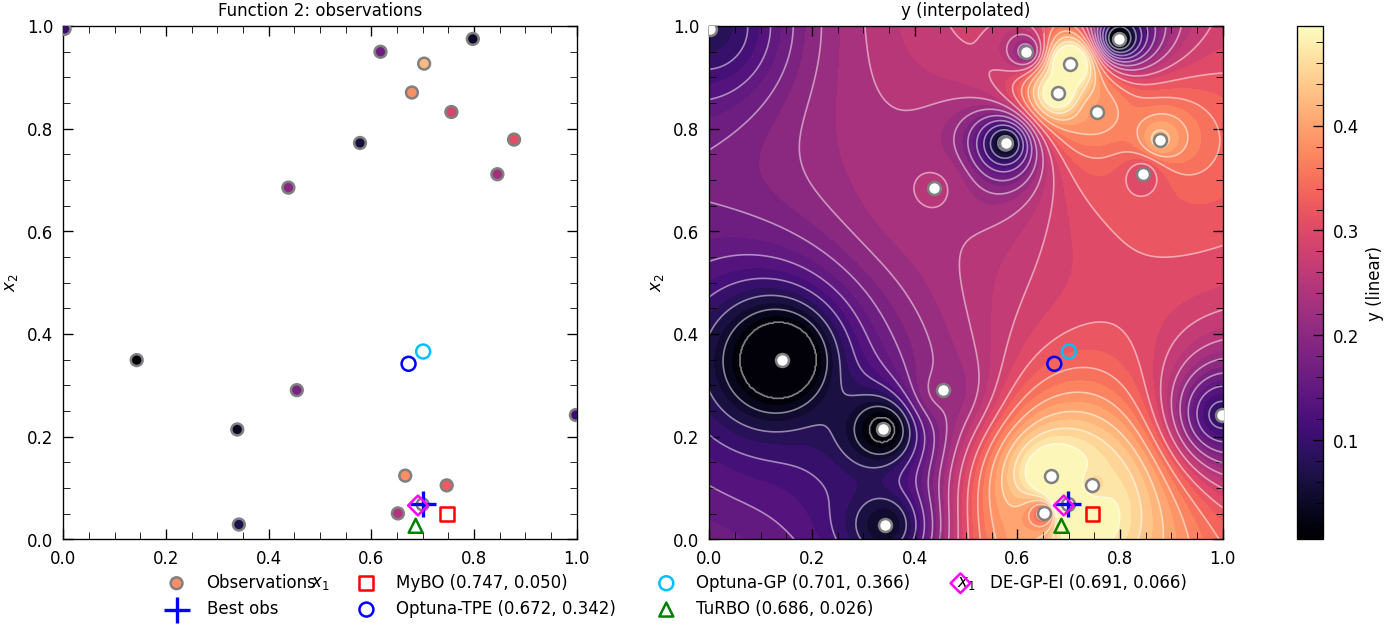

In [88]:
# MyBO = this notebook's next_x (Section 4). Optuna & TuRBO = external HPO wrappers.
from src.utils.compare_solvers import (
    SOLVER_STYLE as _SOLVER_STYLE,
    FALLBACK_STYLES as _FALLBACK_STYLES,
    collect_external_solver_suggestions,
)

bounds_01 = [(0.0, 1.0)] * 2
suggestions = [("MyBO", np.asarray(next_x).ravel())]
suggestions.extend(
    collect_external_solver_suggestions(X, y, bounds=bounds_01, function_id=2)
)

# ==== Summary plot: y interpolated (IDW, same grid as Section 2) ====
dist_gx_s6 = np.sqrt(((grid_pts[:, None, :] - X[None, :, :]) ** 2).sum(axis=2)) + 1e-12
w_s6 = 1.0 / (dist_gx_s6 ** 2)
Y_grid_s6 = ((w_s6 * y[None, :]).sum(axis=1) / w_s6.sum(axis=1)).reshape(X1g.shape)
try:
    _idw_symlog_s6 = (WARP_LABEL != "None")
except NameError:
    _idw_symlog_s6 = False
Y_grid_plot_s6, y_levels_s6, y_norm_s6 = _prepare_surface_for_plot(Y_grid_s6, force_symlog=_idw_symlog_s6)
# Norm for left panel from observation y so points span the colormap (grid norm can make them all black)
import matplotlib.colors as mcolors
_y_flat = np.asarray(y).ravel()
_y_f = _y_flat[np.isfinite(_y_flat)]
if _y_f.size > 0:
    _ymin, _ymax = float(np.min(_y_f)), float(np.max(_y_f))
    if _idw_symlog_s6 and (_ymax > 0 or _ymin < 0):
        _scale = max(abs(_ymin), abs(_ymax), 1e-30)
        _sig = _y_f[np.abs(_y_f) > _scale * 1e-8]
        _linthresh = float(np.percentile(np.abs(_sig), 10)) if len(_sig) > 0 else _scale * 1e-4
        _linthresh = max(_linthresh, 1e-30)
        y_scatter_norm_s6 = mcolors.SymLogNorm(linthresh=_linthresh, vmin=_ymin, vmax=_ymax)
    else:
        y_scatter_norm_s6 = mcolors.Normalize(vmin=_ymin, vmax=_ymax)
else:
    y_scatter_norm_s6 = y_norm_s6

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=F2_FIG_1X2)

# Left: scatter (observations coloured by y; best is one of the points, no separate + marker)
ax1.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap="magma", norm=y_scatter_norm_s6,
            edgecolors="gray", linewidths=1.5, zorder=5, label="Observations")
ax1.scatter(*best_x_so_far, s=250, marker="+", c="blue", linewidths=2, zorder=8, label="Best obs")
for idx, (name, x_pt) in enumerate(suggestions):
    mk, col = _SOLVER_STYLE.get(name, _FALLBACK_STYLES[min(idx, len(_FALLBACK_STYLES)-1)])
    if mk in ("x", "+"):
        ax1.scatter(x_pt[0], x_pt[1], s=70, marker=mk, c=col, linewidths=2, zorder=12,
                    label=f"{name} ({x_pt[0]:.3f}, {x_pt[1]:.3f})")
    else:
        ax1.scatter(x_pt[0], x_pt[1], s=70, marker=mk, c="none", edgecolors=col, linewidths=1.5,
                    zorder=12, label=f"{name} ({x_pt[0]:.3f}, {x_pt[1]:.3f})")
ax1.set_xlabel(r"$x_1$"); ax1.set_ylabel(r"$x_2$")
ax1.set_title("Function 2: observations")
ax1.set_aspect("equal"); ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)
# Right: y (interpolated), same surface
cf2 = ax2.contourf(X1g, X2g, Y_grid_plot_s6, levels=y_levels_s6, norm=y_norm_s6, cmap="magma")
ax2.contour(X1g, X2g, Y_grid_plot_s6, levels=y_levels_s6[::max(1, len(y_levels_s6)//11)],
            colors="white", linewidths=1.0, linestyles="-", alpha=0.5)
ax2.scatter(X[:, 0], X[:, 1], c="white", s=60, edgecolors="gray", zorder=5, linewidths=1.5,
            label="Observations")
ax2.scatter(*best_x_so_far, s=250, marker="+", c="blue", linewidths=2, zorder=8, label="Best obs")
for idx, (name, x_pt) in enumerate(suggestions):
    mk, col = _SOLVER_STYLE.get(name, _FALLBACK_STYLES[min(idx, len(_FALLBACK_STYLES)-1)])
    if mk in ("x", "+"):
        ax2.scatter(x_pt[0], x_pt[1], s=70, marker=mk, c=col, linewidths=2, zorder=12,
                    label=f"{name} ({x_pt[0]:.3f}, {x_pt[1]:.3f})")
    else:
        ax2.scatter(x_pt[0], x_pt[1], s=70, marker=mk, c="none", edgecolors=col, linewidths=1.5,
                    zorder=12, label=f"{name} ({x_pt[0]:.3f}, {x_pt[1]:.3f})")
ax2.set_xlabel(r"$x_1$"); ax2.set_ylabel(r"$x_2$")
ax2.set_title("y (interpolated)")
ax2.set_aspect("equal"); ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)

_scale_lbl_s6 = "SymLog scale" if hasattr(y_norm_s6, 'linthresh') else "linear"
sm_s6 = plt.cm.ScalarMappable(norm=y_norm_s6, cmap="magma")
fig2.colorbar(sm_s6, ax=[ax1, ax2], shrink=1, label=f"y ({_scale_lbl_s6})")
_hs6, _ls6 = ax1.get_legend_handles_labels()
fig2.legend(_hs6, _ls6, loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=4, framealpha=0.95)
if IF_SHOW_PLOT:
    plt.show()
if IF_EXPORT_PLOT:
    out_path = PLOT_EXPORT_DIR / "function_2_section6_summary.png"
    assert_not_under_initial_data(PLOT_EXPORT_DIR, project_root=repo_root)
    PLOT_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    fig2.savefig(out_path, dpi=150, bbox_inches="tight")
    print("Saved function_2_section6_summary.png")